In [1]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pymongo import MongoClient
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from dotenv import load_dotenv
import os
import logging

In [2]:
# logging set up 

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler("analysis.log"),
        logging.StreamHandler()
    ]
)
log = logging.getLogger(__name__)

load_dotenv()

True

### 1. Pulling Data from MongoDB

In [3]:
try:
    mongo_uri = os.getenv("MONGO_URI")
    if not mongo_uri:
        raise ValueError("MONGO_URI not found in .env file")

    client = MongoClient(mongo_uri, serverSelectionTimeoutMS=5000) # establishes a connection pool to the Atlas cluster
    client.server_info()
    log.info("Connected to MongoDB successfully")

    collection = client["data_by_design"]["election_economics"]  # returns a cursor of all documents matching the filter ({} = all)
    df = pd.DataFrame(list(collection.find({}, {"_id": 0})))
    log.info(f"Loaded {len(df)} documents from MongoDB")

except ValueError as e:
    log.error(f"Configuration error: {e}")
    raise
except Exception as e:
    log.error(f"MongoDB connection failed: {e}")
    raise

2026-04-22 15:02:34,557 [INFO] Connected to MongoDB successfully
2026-04-22 15:02:34,665 [INFO] Loaded 612 documents from MongoDB


In [5]:
# clean data
before = len(df)
df = df.dropna(subset=["gas_price_change_pct", "inflation_rate"])
dropped = before - len(df)
log.info(f"Dropped {dropped} rows with missing economic indicators (2020)")
log.info(f"Working with {len(df)} documents across {df['year'].nunique()} election years")

2026-04-22 15:02:38,964 [INFO] Dropped 0 rows with missing economic indicators (2020)
2026-04-22 15:02:38,965 [INFO] Working with 561 documents across 11 election years


### 2. Aggregating to national level

In [6]:
try:
    national = df.groupby(["year", "incumbent_party", "gas_price_change_pct", "inflation_rate"]) \
                 .agg(avg_vote_share=("incumbent_vote_share", "mean")) \
                 .reset_index() \
                 .sort_values("year") # ascending order
    log.info(f"Aggregated to national level: {len(national)} election years")
    log.info(f"\n{national.to_string(index=False)}")
except Exception as e:
    log.error(f"Aggregation failed: {e}")
    raise

2026-04-22 15:02:40,764 [INFO] Aggregated to national level: 11 election years
2026-04-22 15:02:40,768 [INFO] 
 year incumbent_party  gas_price_change_pct  inflation_rate  avg_vote_share
 1980        DEMOCRAT                 37.85           13.50       39.910980
 1984      REPUBLICAN                 -2.33            4.37       59.707059
 1988      REPUBLICAN                 -0.24            4.10       53.662745
 1992      REPUBLICAN                 -1.19            3.04       37.555098
 1996        DEMOCRAT                  7.30            2.94       47.909608
 2000        DEMOCRAT                 29.60            3.37       45.919020
 2004      REPUBLICAN                 18.19            2.67       52.219804
 2008      REPUBLICAN                 16.63            3.81       46.946078
 2012        DEMOCRAT                  3.33            2.07       48.941569
 2016        DEMOCRAT                -12.50            1.27       44.568627
 2020      REPUBLICAN                -17.52          

### 3. Correlation matrix

In [7]:
try:
    corr = national[["avg_vote_share", "gas_price_change_pct", "inflation_rate"]].corr()
    log.info(f"Correlation matrix:\n{corr.round(3)}")
except Exception as e:
    log.error(f"Correlation matrix failed: {e}")
    raise

2026-04-22 15:02:42,808 [INFO] Correlation matrix:
                      avg_vote_share  gas_price_change_pct  inflation_rate
avg_vote_share                 1.000                -0.276          -0.298
gas_price_change_pct          -0.276                 1.000           0.689
inflation_rate                -0.298                 0.689           1.000


### 4. Regression: Vote Share &  Gas Price Change

Rationale: Gas prices are one of the most visible economic indicators in American life, appearing on signs at every street corner and directly affecting the daily budget of nearly every household, making them a natural first candidate for explaining electoral outcomes. A simple linear regression between year-over-year gas price change and incumbent vote share isolates this single relationship and allows us to quantify both the direction and magnitude of the association. Specifically, whether rising prices at the pump translate into measurable losses at the polls. This model serves as a baseline that is easy to interpret and communicate to a non-technical audience, which is particularly important given the press release framing of this project.

In [8]:
try:
    X_gas = national[["gas_price_change_pct"]].values
    y = national["avg_vote_share"].values

    model_gas = LinearRegression().fit(X_gas, y)
    y_pred_gas = model_gas.predict(X_gas)
    r2_gas = r2_score(y, y_pred_gas) # compares predicted vs actual values

    log.info(f"Gas price regression — coef: {model_gas.coef_[0]:.4f}, "
             f"intercept: {model_gas.intercept_:.4f}, R²: {r2_gas:.4f}")
    log.info(f"Interpretation: A 1% increase in gas prices is associated with a "
             f"{model_gas.coef_[0]:.3f}% change in incumbent vote share")
except Exception as e:
    log.error(f"Gas price regression failed: {e}")
    raise

2026-04-22 15:02:45,647 [INFO] Gas price regression — coef: -0.1002, intercept: 48.5844, R²: 0.0760
2026-04-22 15:02:45,648 [INFO] Interpretation: A 1% increase in gas prices is associated with a -0.100% change in incumbent vote share


### 5. Regression: Vote Share & Inflation Rate

Rationale: While gas prices capture a specific and highly visible cost, inflation rate measured by CPI captures the broader experience of economic hardship across all consumer goods and services, making it a complementary indicator that reflects the overall purchasing power of voters. A separate simple regression on inflation allows us to assess whether the general cost of living or the specific cost of gasoline is a stronger predictor of incumbent performance. This analysis also directly engages with the academic literature, particularly Doti and Campbell (2023), who found CPI to be a highly significant predictor of incumbent vote share across 17 presidential elections.

In [9]:
try:
    X_inf = national[["inflation_rate"]].values 

    model_inf = LinearRegression().fit(X_inf, y)
    y_pred_inf = model_inf.predict(X_inf)
    r2_inf = r2_score(y, y_pred_inf)

    log.info(f"Inflation regression — coef: {model_inf.coef_[0]:.4f}, "
             f"intercept: {model_inf.intercept_:.4f}, R²: {r2_inf:.4f}")
    log.info(f"Interpretation: A 1% increase in inflation is associated with a "
             f"{model_inf.coef_[0]:.3f}% change in incumbent vote share")
except Exception as e:
    log.error(f"Inflation regression failed: {e}")
    raise

2026-04-22 15:02:50,948 [INFO] Inflation regression — coef: -0.5460, intercept: 49.9674, R²: 0.0886
2026-04-22 15:02:50,949 [INFO] Interpretation: A 1% increase in inflation is associated with a -0.546% change in incumbent vote share


### 6. Multiple Regression: Vote Share ~ Gas & Inflation 

Rationale: The multiple regression model combines both economic indicators into a single framework to assess whether they jointly explain more variation in incumbent vote share than either does alone, and to determine whether each indicator retains its predictive power after controlling for the other. This is important because gas prices and inflation are correlated with each other (rising oil prices contribute to broader inflation) so examining them in isolation may overstate the independent effect of each, and the multiple regression helps disentangle these overlapping signals. The R² from this model compared against the two simple regressions provides a concrete measure of how much explanatory power is gained by considering both indicators simultaneously, which speaks directly to the complexity of economic voting behavior.

In [10]:
try:
    X_multi = national[["gas_price_change_pct", "inflation_rate"]].values  # model finds the best plane (not line) through the data in 3D space

    model_multi = LinearRegression().fit(X_multi, y)
    y_pred_multi = model_multi.predict(X_multi)
    r2_multi = r2_score(y, y_pred_multi)

    log.info(f"Multiple regression — gas coef: {model_multi.coef_[0]:.4f}, "
             f"inflation coef: {model_multi.coef_[1]:.4f}, "
             f"intercept: {model_multi.intercept_:.4f}, R²: {r2_multi:.4f}")
except Exception as e:
    log.error(f"Multiple regression failed: {e}")
    raise

2026-04-22 15:02:53,020 [INFO] Multiple regression — gas coef: -0.0489, inflation coef: -0.3759, intercept: 49.6638, R²: 0.0981


### 7. Visualizations

Rationale: The four-panel visualization serves as the primary communication tool for this project, translating the statistical findings into a format that is accessible to the non-technical audience described in the press release, where abstract regression coefficients are less meaningful than a chart showing 1980 (the year of peak inflation and gas prices) as a clear outlier where the incumbent Democrat lost decisively. Presenting vote share as colored bars distinguishes Republican from Democrat incumbents at a glance, which is essential context because the relationship between economic conditions and electoral outcomes may differ by party. The scatter plots with overlaid regression lines allow the reader to simultaneously see the overall trend, the individual election years as labeled data points, and the R² as a measure of how tightly the data clusters around that trend. This gives both the finding and an honest signal of its uncertainty in a single visual.

2026-04-22 15:02:55,422 [INFO] Chart saved to economic_voting_analysis.png


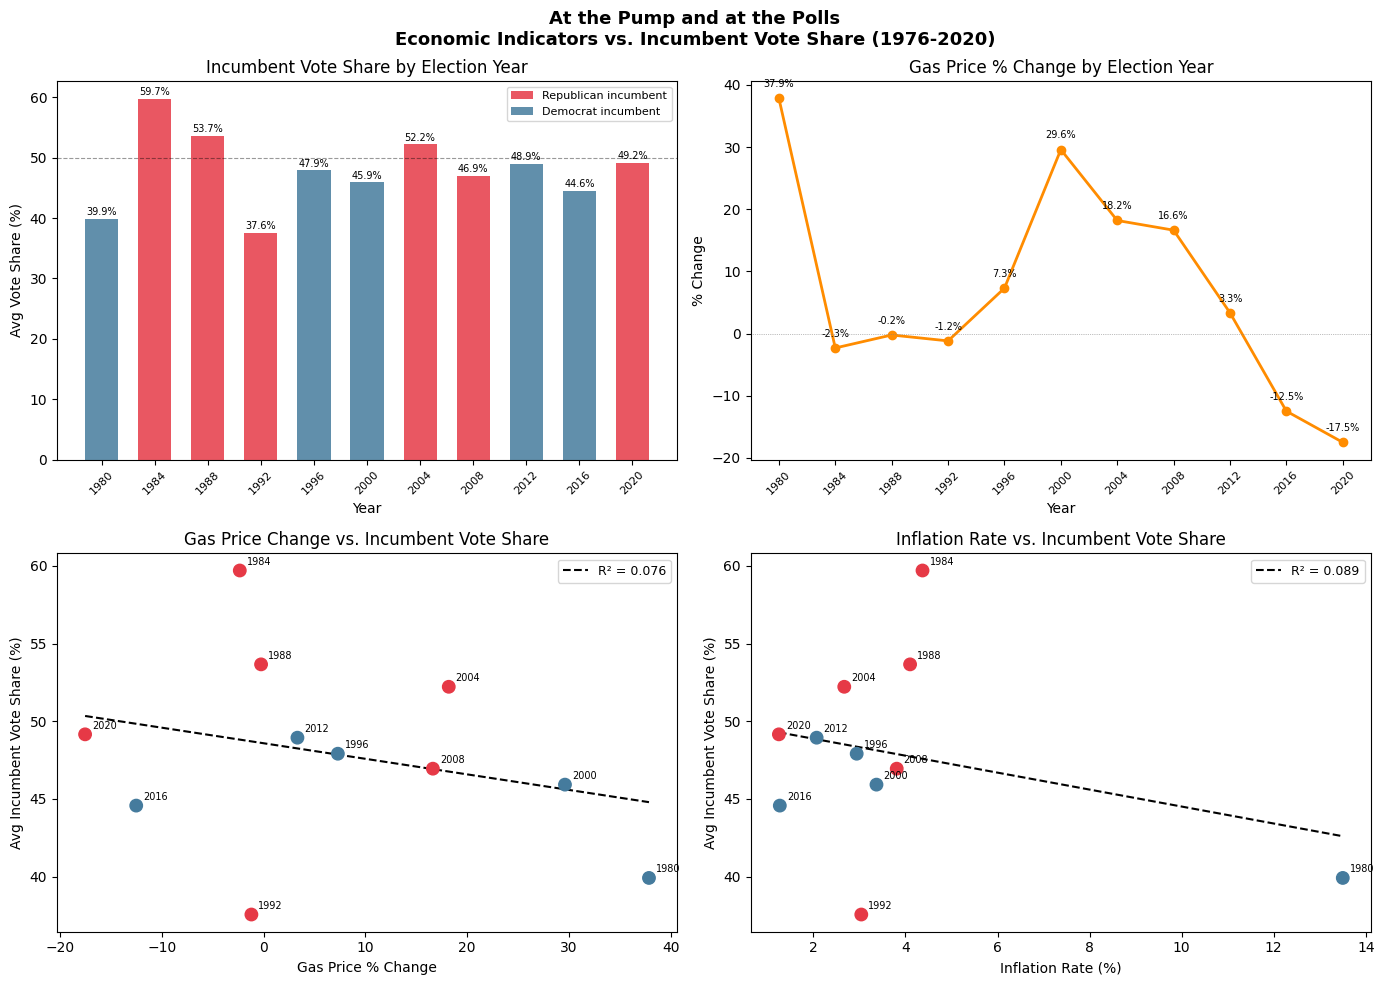

In [11]:
try:
    colors = ["#E63946" if p == "REPUBLICAN" else "#457B9D"
              for p in national["incumbent_party"]]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("At the Pump and at the Polls\nEconomic Indicators vs. Incumbent Vote Share (1976-2020)",
                 fontsize=13, fontweight="bold")

    # Plot 1: Vote share over time
    ax1 = axes[0, 0]
    bars = ax1.bar(national["year"], national["avg_vote_share"],
                   color=colors, width=2.5, alpha=0.85)
    ax1.axhline(50, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
    ax1.set_title("Incumbent Vote Share by Election Year")
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Avg Vote Share (%)")
    ax1.set_xticks(national["year"])
    ax1.set_xticklabels(national["year"], rotation=45, fontsize=8)
    for bar, val in zip(bars, national["avg_vote_share"]):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=7)
    legend_elements = [
        Patch(facecolor="#E63946", alpha=0.85, label="Republican incumbent"),
        Patch(facecolor="#457B9D", alpha=0.85, label="Democrat incumbent")
    ]
    ax1.legend(handles=legend_elements, fontsize=8)

    # Plot 2: Gas price change over time
    ax2 = axes[0, 1]
    ax2.plot(national["year"], national["gas_price_change_pct"],
             color="darkorange", marker="o", linewidth=2, markersize=6)
    ax2.axhline(0, color="grey", linewidth=0.5, linestyle=":")
    ax2.set_title("Gas Price % Change by Election Year")
    ax2.set_xlabel("Year")
    ax2.set_ylabel("% Change")
    ax2.set_xticks(national["year"])
    ax2.set_xticklabels(national["year"], rotation=45, fontsize=8)
    for x, y_val in zip(national["year"], national["gas_price_change_pct"]):
        ax2.annotate(f"{y_val:.1f}%", (x, y_val),
                     textcoords="offset points", xytext=(0, 8),
                     ha="center", fontsize=7)

    # Plot 3: Scatter — gas price vs vote share
    ax3 = axes[1, 0]
    ax3.scatter(national["gas_price_change_pct"], national["avg_vote_share"],
                color=colors, s=80, zorder=3)
    x_range = np.linspace(national["gas_price_change_pct"].min(),
                          national["gas_price_change_pct"].max(), 100).reshape(-1, 1)
    ax3.plot(x_range, model_gas.predict(x_range),
             color="black", linewidth=1.5, linestyle="--", label=f"R² = {r2_gas:.3f}")
    for _, row in national.iterrows():
        ax3.annotate(str(int(row["year"])),
                     (row["gas_price_change_pct"], row["avg_vote_share"]),
                     textcoords="offset points", xytext=(5, 4), fontsize=7)
    ax3.set_title("Gas Price Change vs. Incumbent Vote Share")
    ax3.set_xlabel("Gas Price % Change")
    ax3.set_ylabel("Avg Incumbent Vote Share (%)")
    ax3.legend(fontsize=9)

    # Plot 4: Scatter — inflation vs vote share
    ax4 = axes[1, 1]
    ax4.scatter(national["inflation_rate"], national["avg_vote_share"],
                color=colors, s=80, zorder=3)
    x_range_inf = np.linspace(national["inflation_rate"].min(),
                               national["inflation_rate"].max(), 100).reshape(-1, 1)
    ax4.plot(x_range_inf, model_inf.predict(x_range_inf),
             color="black", linewidth=1.5, linestyle="--", label=f"R² = {r2_inf:.3f}")
    for _, row in national.iterrows():
        ax4.annotate(str(int(row["year"])),
                     (row["inflation_rate"], row["avg_vote_share"]),
                     textcoords="offset points", xytext=(5, 4), fontsize=7)
    ax4.set_title("Inflation Rate vs. Incumbent Vote Share")
    ax4.set_xlabel("Inflation Rate (%)")
    ax4.set_ylabel("Avg Incumbent Vote Share (%)")
    ax4.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("economic_voting_analysis.png", dpi=150, bbox_inches="tight")
    log.info("Chart saved to economic_voting_analysis.png")
    plt.show()

except Exception as e:
    log.error(f"Visualization failed: {e}")
    raise

### 8. Model Comparison Summary 

In [11]:
try:
    summary = pd.DataFrame({
        "Model": ["Gas Price Only", "Inflation Only", "Gas + Inflation"],
        "R²": [round(r2_gas, 3), round(r2_inf, 3), round(r2_multi, 3)]
    })
    log.info(f"Model comparison:\n{summary.to_string(index=False)}")
except Exception as e:
    log.error(f"Model summary failed: {e}")
    raise

log.info("Analysis pipeline complete")

2026-04-19 23:28:18,729 [INFO] Model comparison:
          Model    R²
 Gas Price Only 0.076
 Inflation Only 0.089
Gas + Inflation 0.098
2026-04-19 23:28:18,734 [INFO] Analysis pipeline complete
